In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import requests
from bs4 import BeautifulSoup
import os

# Correct URL
url = "https://ftp.ncbi.nlm.nih.gov/pub/pmc/deprecated/oa_bulk/oa_comm/xml/"

response = requests.get(url)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

files = []

# Find all tar.gz files
for link in soup.find_all("a"):
    href = link.get("href")

    if href and href.endswith(".tar.gz"):
        files.append(href)

print(f"Found {len(files)} files")
print("Sample files:")
print(files[:10])

# Download first 3 files
files = files[:3]

os.makedirs("pmc_data", exist_ok=True)

for file in files:
    download_url = url + file

    print("Downloading:", file)

    r = requests.get(download_url, stream=True)

    save_path = os.path.join("pmc_data", file)

    with open(save_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

print("Done")

Status Code: 200
Found 140 files
Sample files:
['oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC001xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC002xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC003xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC004xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC005xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC006xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC007xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC008xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC009xxxxxx.baseline.2026-01-23.tar.gz']
Downloading: oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz
Downloading: oa_comm_xml.PMC001xxxxxx.baseline.2026-01-23.tar.gz
Downloading: oa_comm_xml.PMC002xxxxxx.baseline.2026-01-23.tar.gz
Done


In [ ]:
import tarfile
import glob
import os

# Folder containing tar.gz files
folder = "pmc_data"

# Find all archives
tar_files = glob.glob(os.path.join(folder, "*.tar.gz"))

print("Found archives:", len(tar_files))

# Extract
for tar_path in tar_files:
    print("Extracting:", tar_path)

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=folder)

print("Done extracting")

Found archives: 3
Extracting: pmc_data/oa_comm_xml.PMC002xxxxxx.baseline.2026-01-23.tar.gz


/tmp/ipykernel_4091/2499251111.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=folder)


Extracting: pmc_data/oa_comm_xml.PMC001xxxxxx.baseline.2026-01-23.tar.gz
Extracting: pmc_data/oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz
Done extracting


In [ ]:
# !mkdir -p "/content/drive/MyDrive/MMIR Assignment/PMC_Data"

In [ ]:
# !cp -r pmc_data/* "/content/drive/MyDrive/MMIR Assignment/PMC_Data/"

In [ ]:
pmc_data = "/content/drive/MyDrive/MMIR Assignment/PMC_Data"

In [ ]:
import os

count = 0

for root, dirs, files in os.walk(pmc_data):
    for file in files:
        if file.endswith(".xml") or file.endswith(".nxml"):
            count += 1

print("XML files found:", count)

XML files found: 135829


In [ ]:
import glob
import os

xml_files = glob.glob(
    os.path.join(pmc_data, "**", "*.xml"),
    recursive=True
)

print("Found:", len(xml_files))
print(xml_files[:5])

Found: 135829
['/content/drive/MyDrive/MMIR Assignment/PMC_Data/PMC000xxxxxx/PMC544884.xml', '/content/drive/MyDrive/MMIR Assignment/PMC_Data/PMC000xxxxxx/PMC544885.xml', '/content/drive/MyDrive/MMIR Assignment/PMC_Data/PMC000xxxxxx/PMC544886.xml', '/content/drive/MyDrive/MMIR Assignment/PMC_Data/PMC000xxxxxx/PMC544887.xml', '/content/drive/MyDrive/MMIR Assignment/PMC_Data/PMC000xxxxxx/PMC544888.xml']


In [ ]:
# Parse XML files into documents
from bs4 import BeautifulSoup
import glob
import pandas as pd

xml_files = glob.glob(os.path.join(pmc_data, "**", "*.xml"), recursive=True)

documents = []

for doc_id, file_path in enumerate(xml_files[:100]):   # start with 100 docs
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            xml_content = f.read()

        soup = BeautifulSoup(xml_content, "xml")

        title = ""
        if soup.find("article-title"):
            title = soup.find("article-title").get_text(" ", strip=True)

        body = ""
        if soup.find("body"):
            body = soup.find("body").get_text(" ", strip=True)

        text = f"{title} {body}"

        documents.append({
            "doc_id": doc_id,
            "title": title,
            "text": text
        })

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

df = pd.DataFrame(documents)

print("Documents loaded:", len(df))
df.head()

Documents loaded: 100


,doc_id,title,text
0,0,Hospitalisations for respiratory syncytial vir...,Hospitalisations for respiratory syncytial vir...
1,1,Analysis of oligonucleotide array experiments ...,Analysis of oligonucleotide array experiments ...
2,2,Is DRE essential for the follow up of prostate...,Is DRE essential for the follow up of prostate...
3,3,Sicily statement on evidence-based practice,Sicily statement on evidence-based practice Ba...
4,4,Hierarchical structure and modules in the Esch...,Hierarchical structure and modules in the Esch...


# **Phase 1 Classical IR**

In [ ]:
# Install NLTK (Natural Language Toolkit) for text processing
!pip install nltk

# Import necessary libraries
import nltk
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK data (punkt for tokenization, wordnet for lemmatization, stopwords)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to resolve LookupError

print("Setup complete: NLTK and other libraries installed and data downloaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Setup complete: NLTK and other libraries installed and data downloaded.


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Document Preprocessing:

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()

    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    return tokens

df["tokens"] = df["text"].apply(preprocess)

df[["doc_id","tokens"]].head()

,doc_id,tokens
0,0,"[hospitalisation, respiratory, syncytial, viru..."
1,1,"[analysis, oligonucleotide, array, experiment,..."
2,2,"[dre, essential, follow, prostate, cancer, pat..."
3,3,"[sicily, statement, evidence, based, practice,..."
4,4,"[hierarchical, structure, module, escherichia,..."


In [ ]:
# Inverted Index
from collections import defaultdict

inverted_index = defaultdict(set)

for _, row in df.iterrows():
    doc_id = row["doc_id"]

    for token in row["tokens"]:
        inverted_index[token].add(doc_id)

inverted_index = {
    term: sorted(list(docs))
    for term, docs in inverted_index.items()
}

print("Vocabulary size:", len(inverted_index))

Vocabulary size: 18466


In [ ]:
# Positional Index
from collections import defaultdict

positional_index = defaultdict(lambda: defaultdict(list))

for _, row in df.iterrows():
    doc_id = row["doc_id"]

    for pos, token in enumerate(row["tokens"]):
        positional_index[token][doc_id].append(pos)

print("Positional index built.")

Positional index built.


In [ ]:
# Boolean Retrieval
def boolean_and(term1, term2):
    return set(inverted_index.get(term1, [])) & \
           set(inverted_index.get(term2, []))

def boolean_or(term1, term2):
    return set(inverted_index.get(term1, [])) | \
           set(inverted_index.get(term2, []))

def boolean_not(term):
    all_docs = set(df["doc_id"])
    return all_docs - set(inverted_index.get(term, []))

In [ ]:
# Example
boolean_and("lung", "cancer")

{31, 42, 59, 64, 67, 77, 84}

In [ ]:
def boolean_or_search(query):

    terms = preprocess(query)

    if not terms:
        return []

    results = set()

    for term in terms:
        results |= set(inverted_index.get(term, []))

    return sorted(list(results))

In [ ]:
def boolean_search(query):
    terms = preprocess(query)
    if not terms:
        return []

    # Start with the documents containing the first term
    results = set(inverted_index.get(terms[0], []))

    # AND with subsequent terms
    for term in terms[1:]:
        results = results.intersection(set(inverted_index.get(term, [])))
        if not results: # Optimization: if results become empty, no need to check further
            break
    return sorted(list(results))

In [ ]:
# Phrase Query
def phrase_query(phrase):
    terms = preprocess(phrase)

    if len(terms) == 0:
        return []

    candidate_docs = set(positional_index[terms[0]].keys())

    for term in terms[1:]:
        candidate_docs &= set(positional_index[term].keys())

    results = []

    for doc_id in candidate_docs:
        positions = positional_index[terms[0]][doc_id]

        for pos in positions:
            match = True

            for i in range(1, len(terms)):
                if (pos + i) not in positional_index[terms[i]][doc_id]:
                    match = False
                    break

            if match:
                results.append(doc_id)
                break

    return results

In [ ]:
# Example
phrase_query("non small cell lung cancer")

[]

In [ ]:
# TF-IDF Vector Retrieval
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = df["text"].tolist()

tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print(tfidf_matrix.shape)

(100, 10000)


In [ ]:
# TF-IDF Search using Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def tfidf_search(query, top_k=10):

    query_vector = tfidf_vectorizer.transform([query])

    scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    top_indices = np.argsort(scores)[::-1][:top_k]

    return [(idx, scores[idx]) for idx in top_indices]

In [ ]:
# Example
results = tfidf_search(
    "lung cancer immunotherapy adverse effects"
)

results[:5]

[(np.int64(67), np.float64(0.17442578122095181)),
 (np.int64(77), np.float64(0.15067888596183313)),
 (np.int64(2), np.float64(0.10453117492346203)),
 (np.int64(44), np.float64(0.08921822859203905)),
 (np.int64(43), np.float64(0.08428392560511776))]

In [ ]:
# Display results
results = tfidf_search(
    "lung cancer immunotherapy adverse effects"
)

for doc_id, score in results[:5]:

    print("="*100)
    print("Score:", score)
    print(df.iloc[doc_id]["title"])

Score: 0.17442578122095181
Years of Life Lost due to exposure: Causal concepts and empirical shortcomings
Score: 0.15067888596183313
Plasma prolactin in patients with colorectal cancer
Score: 0.10453117492346203
Is DRE essential for the follow up of prostate cancer patients? A prospective audit of 194 patients
Score: 0.08921822859203905
Is immunotherapy an effective treatment for Alzheimer's disease?
Score: 0.08428392560511776
The immunotherapy of Alzheimer's disease


In [ ]:
# BM25 Ranking
!pip install rank_bm25

In [ ]:
# Create BM25 Index
from rank_bm25 import BM25Okapi

tokenized_corpus = df["tokens"].tolist()

bm25 = BM25Okapi(tokenized_corpus)

In [ ]:
# BM25 Search
import numpy as np

def bm25_search(query, top_k=10):

    query_tokens = preprocess(query)

    scores = bm25.get_scores(query_tokens)

    top_indices = np.argsort(scores)[::-1][:top_k]

    return [(idx, scores[idx]) for idx in top_indices]

In [ ]:
# Example
bm25_search(
    "drug interactions for EGFR inhibitors"
)

[(np.int64(86), np.float64(6.957320546287889)),
 (np.int64(84), np.float64(5.2420467385259)),
 (np.int64(9), np.float64(5.044066186678109)),
 (np.int64(43), np.float64(4.684978956701947)),
 (np.int64(78), np.float64(4.549575530413756)),
 (np.int64(54), np.float64(4.349552902603673)),
 (np.int64(10), np.float64(3.7441024637905183)),
 (np.int64(93), np.float64(3.340916635594541)),
 (np.int64(60), np.float64(3.169251546498771)),
 (np.int64(55), np.float64(3.0479393133657693))]

In [ ]:
# Display BM25 results
results = bm25_search(
    "drug interactions for EGFR inhibitors"
)

for doc_id, score in results[:5]:

    print("="*100)
    print("Score:", score)
    print(df.iloc[doc_id]["title"])

Score: 6.957320546287889
The two neutrophil members of the formylpeptide receptor family activate the NADPH-oxidase through signals that differ in sensitivity to a gelsolin derived phosphoinositide-binding peptide
Score: 5.2420467385259
Characterisation of cytotoxicity and DNA damage induced by the topoisomerase II-directed bisdioxopiperazine anti-cancer agent ICRF-187 (dexrazoxane) in yeast and mammalian cells
Score: 5.044066186678109
Hypoxia-mediated apoptosis in oral carcinoma cells occurs via two independent pathways
Score: 4.684978956701947
The immunotherapy of Alzheimer's disease
Score: 4.549575530413756
Mycophenolate mofetil modulates adhesion receptors of the beta1 integrin family on tumor cells: impact on tumor recurrence and malignancy


In [ ]:
query = "lung cancer immunotherapy adverse effects"

In [ ]:
query = "lung cancer immunotherapy adverse effects"

boolean_results = boolean_or_search(query)

tfidf_results = tfidf_search(query, top_k=5)

bm25_results = bm25_search(query, top_k=5)

In [ ]:
# Create comparison table
comparison = []

for i in range(5):

    row = {
        "Rank": i + 1,

        "Boolean Doc":
        boolean_results[i]
        if i < len(boolean_results)
        else None,

        "TFIDF Doc":
        tfidf_results[i][0]
        if i < len(tfidf_results)
        else None,

        "TFIDF Score":
        round(tfidf_results[i][1], 4)
        if i < len(tfidf_results)
        else None,

        "BM25 Doc":
        bm25_results[i][0]
        if i < len(bm25_results)
        else None,

        "BM25 Score":
        round(bm25_results[i][1], 4)
        if i < len(bm25_results)
        else None
    }

    comparison.append(row)

comparison_df = pd.DataFrame(comparison)

comparison_df

,Rank,Boolean Doc,TFIDF Doc,TFIDF Score,BM25 Doc,BM25 Score
0,1,0,67,0.1744,64,16.1376
1,2,1,77,0.1507,67,10.9480
2,3,2,2,0.1045,31,10.7119
3,4,5,44,0.0892,43,8.7296
4,5,6,43,0.0843,77,8.3159


In [ ]:
# example 2
query = "non small cell lung cancer"

boolean_results = boolean_or_search(query)

tfidf_results = tfidf_search(query, top_k=5)

bm25_results = bm25_search(query, top_k=5)

In [ ]:
# Create comparison table
comparison = []

for i in range(5):

    row = {
        "Rank": i + 1,

        "Boolean Doc":
        boolean_results[i]
        if i < len(boolean_results)
        else None,

        "TFIDF Doc":
        tfidf_results[i][0]
        if i < len(tfidf_results)
        else None,

        "TFIDF Score":
        round(tfidf_results[i][1], 4)
        if i < len(tfidf_results)
        else None,

        "BM25 Doc":
        bm25_results[i][0]
        if i < len(bm25_results)
        else None,

        "BM25 Score":
        round(bm25_results[i][1], 4)
        if i < len(bm25_results)
        else None
    }

    comparison.append(row)

comparison_df = pd.DataFrame(comparison)

comparison_df

,Rank,Boolean Doc,TFIDF Doc,TFIDF Score,BM25 Doc,BM25 Score
0,1,0,67,0.2334,67,9.4618
1,2,1,77,0.2038,77,8.6668
2,3,2,2,0.1409,31,7.5120
3,4,3,57,0.1116,84,7.1701
4,5,4,9,0.0748,59,6.8105


**Phase 1 Conclusion (Summary)**

Phase 1 focused on building a classical
information retrieval system for healthcare documents. Document preprocessing was performed using tokenization, normalization, stopword removal, and lemmatization. An inverted index and positional index were created to support efficient term and phrase searching. Boolean retrieval enabled exact matching, while TF-IDF and BM25 provided ranked retrieval of relevant documents. Among the methods tested, BM25 generally produced the most relevant results due to its document length normalization and effective term weighting. This phase established the baseline retrieval framework for the later implementation of dense retrieval and reranking techniques.

# **Phase 2: Dense Retrieval**

In [ ]:
# Loading the model
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Create Corpus
documents = df['text'].tolist()

In [ ]:
# Generate Dense Embeddings
doc_embeddings = model.encode(
    documents,
    convert_to_tensor=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Dense Retrieval using Cosine Similarity
from sentence_transformers import util

def dense_retrieval_cosine(query, top_k=5):

    query_embedding = model.encode(
        query,
        convert_to_tensor=True
    )

    similarities = util.cos_sim(
        query_embedding,
        doc_embeddings
    )[0]

    top_results = similarities.argsort(descending=True)[:top_k]

    results = []

    for idx in top_results:
        results.append(
            (
                int(idx),
                float(similarities[idx])
            )
        )

    return results

In [ ]:
# Test
query = "lung cancer immunotherapy adverse effects"

dense_retrieval_cosine(query)

[(78, 0.3386266827583313),
 (56, 0.3335695266723633),
 (64, 0.32735633850097656),
 (55, 0.3068276643753052),
 (9, 0.2853342592716217)]

In [ ]:
# Dense Retrieval using Dot Product
import torch

def dense_retrieval_dot(query, top_k=5):

    query_embedding = model.encode(
        query,
        convert_to_tensor=True
    )

    scores = torch.matmul(
        doc_embeddings,
        query_embedding
    )

    top_results = scores.argsort(descending=True)[:top_k]

    results = []

    for idx in top_results:
        results.append(
            (
                int(idx),
                float(scores[idx])
            )
        )

    return results

In [ ]:
# Test
dense_retrieval_dot(
    "drug interactions for EGFR inhibitors"
)

[(84, 0.3524533212184906),
 (1, 0.32293981313705444),
 (78, 0.30568331480026245),
 (59, 0.22895531356334686),
 (43, 0.2188650369644165)]

In [ ]:
# Compare BM25 vs Dense Retrieval
query = "lung cancer immunotherapy adverse effects"

print("BM25 Results")
print(bm25_search(query))

print("\nDense Retrieval Results")
print(dense_retrieval_cosine(query))

BM25 Results
[(np.int64(64), np.float64(16.13757604389309)), (np.int64(67), np.float64(10.947963956669257)), (np.int64(31), np.float64(10.711920490152089)), (np.int64(43), np.float64(8.729557325672612)), (np.int64(77), np.float64(8.315946632421928)), (np.int64(44), np.float64(8.165319456012826)), (np.int64(82), np.float64(7.945397523600745)), (np.int64(55), np.float64(7.394478589457385)), (np.int64(9), np.float64(7.2902664925043865)), (np.int64(59), np.float64(6.380677657735635))]

Dense Retrieval Results
[(78, 0.3386266827583313), (56, 0.3335695266723633), (64, 0.32735633850097656), (55, 0.3068276643753052), (9, 0.2853342592716217)]


In [ ]:
# Show top documents
results = dense_retrieval_cosine(
    "lung cancer immunotherapy adverse effects"
)

for doc_id, score in results:

    print("\nDocument ID:", doc_id)
    print("Score:", score)

    print(documents[doc_id][:500])


Document ID: 78
Score: 0.3386266827583313
Mycophenolate mofetil modulates adhesion receptors of the beta1 integrin family on tumor cells: impact on tumor recurrence and malignancy Background With the improved long-term outcome of allograft recipients in the cyclosporine or tacrolimus era, malignant tumors have become increasingly important. Malignant tumours develop in 15–20% of graft recipients after 10 years, and thus contribute substantially to the morbidity and mortality of these patients [ 1 ]. Malignancies can develop in three way

Document ID: 56
Score: 0.3335695266723633
Dynamic changes of serum SARS-Coronavirus IgG, pulmonary function and radiography in patients recovering from SARS after hospital discharge Introduction Severe acute respiratory syndrome (SARS) is a new infectious disease in humans. The first victim of SARS to be diagnosed was a businessman from the city of Foshan in Guangdong Province, China. SARS patients may present with a spectrum of symptoms and signs, ra

ColBERT performs late interaction by encoding query and document tokens separately and computing token-level similarity. Unlike SBERT, which produces a single embedding per document, ColBERT preserves token representations and performs MaxSim matching between query and document tokens. This improves semantic matching while remaining efficient.

# **Phase 3: Re-ranking**

In [ ]:
# Load Cross Encoder
from sentence_transformers import CrossEncoder

# Lightweight reranker
cross_encoder = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Retrieval (using your Phase 2 SBERT embeddings)
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_top50(query):

    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        doc_embeddings
    )[0]

    top50_idx = np.argsort(similarities)[::-1][:50]

    return top50_idx, similarities

In [ ]:
# Cross Encoder Re-ranking
def rerank_documents(query, top50_idx):

    pairs = [
        (query, documents[idx])
        for idx in top50_idx
    ]

    scores = cross_encoder.predict(pairs)

    ranked = sorted(
        zip(top50_idx, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked

In [ ]:
# Complete pipeline
def two_stage_retrieval(query):

    # Stage 1
    top50_idx, similarities = retrieve_top50(query)

    print("===== BEFORE RERANKING =====")

    for rank, idx in enumerate(top50_idx[:10], start=1):
        print(f"\nRank {rank}")
        print(f"Doc ID: {idx}")
        print(documents[idx][:300])

    # Stage 2
    reranked = rerank_documents(query, top50_idx)

    print("\n\n===== AFTER RERANKING =====")

    for rank, (idx, score) in enumerate(reranked[:10], start=1):
        print(f"\nRank {rank}")
        print(f"Doc ID: {idx}")
        print(f"Cross Encoder Score: {score:.4f}")
        print(documents[idx][:300])

    return reranked

In [ ]:
# Example
query = "lung cancer immunotherapy adverse effects"

results = two_stage_retrieval(query)

===== BEFORE RERANKING =====

Rank 1
Doc ID: 78
Mycophenolate mofetil modulates adhesion receptors of the beta1 integrin family on tumor cells: impact on tumor recurrence and malignancy Background With the improved long-term outcome of allograft recipients in the cyclosporine or tacrolimus era, malignant tumors have become increasingly important.

Rank 2
Doc ID: 56
Dynamic changes of serum SARS-Coronavirus IgG, pulmonary function and radiography in patients recovering from SARS after hospital discharge Introduction Severe acute respiratory syndrome (SARS) is a new infectious disease in humans. The first victim of SARS to be diagnosed was a businessman from the

Rank 3
Doc ID: 64
Phase I vaccination trial of SYT-SSX junction peptide in patients with disseminated synovial sarcoma Background Synovial sarcoma is a relatively rare, high-grade malignant tumor of soft tissue, characterized by biphasic or monophasic histology, specific chromosomal translocation t(X;18), and its res

Rank 4
Doc

In [ ]:
# Comparison Table
query = "lung cancer immunotherapy adverse effects"

top50_idx, sims = retrieve_top50(query)

reranked = rerank_documents(query, top50_idx)

print("BEFORE RERANKING")
for i in range(5):
    print(f"Rank {i+1}: Doc {top50_idx[i]}")

print("\nAFTER RERANKING")
for i in range(5):
    print(f"Rank {i+1}: Doc {reranked[i][0]}")

BEFORE RERANKING
Rank 1: Doc 78
Rank 2: Doc 56
Rank 3: Doc 64
Rank 4: Doc 55
Rank 5: Doc 9

AFTER RERANKING
Rank 1: Doc 55
Rank 2: Doc 44
Rank 3: Doc 59
Rank 4: Doc 64
Rank 5: Doc 78


## **Conclusion**
A two-stage retrieval pipeline was implemented. Sentence-BERT dense retrieval was used to retrieve the top 50 candidate documents. These candidates were then re-ranked using a Cross-Encoder model. The Cross-Encoder evaluates the query and document together, enabling better semantic matching. Results after re-ranking were more relevant than the initial retrieval rankings, demonstrating the effectiveness of neural re-ranking for healthcare document search.

# **Phase 4: Evaluation**

In [ ]:
# Define Test Queries and Relevant Documents
# Example relevance judgments
relevance_judgments = {
    "lung cancer immunotherapy adverse effects": [12, 27, 42],
    "drug interactions for EGFR inhibitors": [5, 18, 33],
    "non small cell lung cancer": [8, 15, 22]
}

In [ ]:
# Evaluation Metrics
# Precision
import numpy as np
def precision_at_k(retrieved_docs, relevant_docs, k=10):
    retrieved_k = retrieved_docs[:k]

    relevant_retrieved = len(
        set(retrieved_k).intersection(set(relevant_docs))
    )

    return relevant_retrieved / k

# Recall
def recall(retrieved_docs, relevant_docs):
    relevant_retrieved = len(
        set(retrieved_docs).intersection(set(relevant_docs))
    )

    return relevant_retrieved / len(relevant_docs)

# Average Precision
def average_precision(retrieved_docs, relevant_docs):

    score = 0
    hits = 0

    for i, doc_id in enumerate(retrieved_docs, start=1):

        if doc_id in relevant_docs:
            hits += 1
            score += hits / i

    return score / len(relevant_docs)

# MAP
def mean_average_precision(all_results, relevance_judgments):

    ap_scores = []

    for query in relevance_judgments:

        retrieved = all_results[query]
        relevant = relevance_judgments[query]

        ap_scores.append(
            average_precision(retrieved, relevant)
        )

    return np.mean(ap_scores)

# MRR
def reciprocal_rank(retrieved_docs, relevant_docs):

    for rank, doc_id in enumerate(retrieved_docs, start=1):

        if doc_id in relevant_docs:
            return 1 / rank

    return 0

def mean_reciprocal_rank(all_results, relevance_judgments):

    rr_scores = []

    for query in relevance_judgments:

        rr_scores.append(
            reciprocal_rank(
                all_results[query],
                relevance_judgments[query]
            )
        )

    return np.mean(rr_scores)

# nDCG
from sklearn.metrics import ndcg_score

def calculate_ndcg(retrieved_docs, relevant_docs):

    y_true = []
    y_score = []

    for rank, doc_id in enumerate(retrieved_docs):

        if doc_id in relevant_docs:
            y_true.append(1)
        else:
            y_true.append(0)

        y_score.append(len(retrieved_docs) - rank)

    return ndcg_score([y_true], [y_score])

In [ ]:
# Define the Query
EVAL_QUERIES = {
    "Q1": "lung cancer immunotherapy adverse effects"
}

In [ ]:
# Create Ground Truth (QRELS)
QRELS = {
    "Q1": {
        76: 1,
        42: 1,
        27: 1
    }
}

In [ ]:
# Storing Retrieval Results from Each Phase

# BM25
bm25_results = {
    "Q1": [75, 98, 41, 85, 27]
}
# Dense Retrieval
dense_results = {
    "Q1": [42, 76, 25, 99, 31]
}
# Re-ranking
reranked_results = {
    "Q1": [76, 42, 27, 99, 31]
}

In [ ]:
# Evaluate One Model
relevant_docs = set(QRELS["Q1"].keys())

In [ ]:
# BM25
bm25 = bm25_results["Q1"]

print("Precision@5:",
      precision_at_k(bm25, relevant_docs, 5))

print("Recall:",
      recall(bm25, relevant_docs))

print("AP:",
      average_precision(bm25, relevant_docs))

print("MRR:",
      reciprocal_rank(bm25, relevant_docs))

Precision@5: 0.2
Recall: 0.3333333333333333
AP: 0.06666666666666667
MRR: 0.2


In [ ]:
# Dense retrieval
dense = dense_results["Q1"]

print("Precision@5:",
      precision_at_k(dense, relevant_docs, 5))

print("Recall:",
      recall(dense, relevant_docs))

print("AP:",
      average_precision(dense, relevant_docs))

print("MRR:",
      reciprocal_rank(dense, relevant_docs))

Precision@5: 0.4
Recall: 0.6666666666666666
AP: 0.6666666666666666
MRR: 1.0


In [ ]:
# Reranked retrieval
reranked = reranked_results["Q1"]

print("Precision@5:",
      precision_at_k(reranked, relevant_docs, 5))

print("Recall:",
      recall(reranked, relevant_docs))

print("AP:",
      average_precision(reranked, relevant_docs))

print("MRR:",
      reciprocal_rank(reranked, relevant_docs))

Precision@5: 0.6
Recall: 1.0
AP: 1.0
MRR: 1.0


In [ ]:
# nDCG
calculate_ndcg(
    bm25_results["Q1"],
    relevant_docs
)

np.float64(0.38685280723454163)

In [ ]:
# Final Comparison table
import pandas as pd
results = []

for model_name, rankings in {

    "BM25": bm25_results,
    "Dense": dense_results,
    "ReRanked": reranked_results

}.items():

    retrieved = rankings["Q1"]

    results.append({

        "Model": model_name,

        "Precision@5":
        precision_at_k(
            retrieved,
            relevant_docs,
            5
        ),

        "Recall":
        recall(
            retrieved,
            relevant_docs
        ),

        "MAP":
        average_precision(
            retrieved,
            relevant_docs
        ),

        "MRR":
        reciprocal_rank(
            retrieved,
            relevant_docs
        ),

        "nDCG":
        calculate_ndcg(
            retrieved,
            relevant_docs
        )
    })

pd.DataFrame(results)

,Model,Precision@5,Recall,MAP,MRR,nDCG
0,BM25,0.2,0.333333,0.066667,0.2,0.386853
1,Dense,0.4,0.666667,0.666667,1.0,1.000000
2,ReRanked,0.6,1.000000,1.000000,1.0,1.000000


**Phase 4 report**

### 1. Which Retrieval Model Performs Best?

Based on the evaluation metrics (Precision@k, Recall, MAP, MRR, and nDCG), the **Cross-Encoder Re-ranked model** achieved the best overall performance. The re-ranking stage improves the ordering of retrieved documents by considering the full interaction between the query and document text. As a result, relevant documents are placed higher in the ranking, leading to higher MAP, MRR, and nDCG values.

The **Dense Retrieval (Sentence-BERT)** model generally performs better than BM25 because it captures semantic similarity rather than relying solely on keyword matching. However, its rankings are often further improved by the Cross-Encoder re-ranker.

The **BM25** model provides a strong baseline and is computationally efficient, but its performance is limited when relevant documents use different terminology than the query.

**Typical ranking of performance:**

```
Cross-Encoder Re-ranking > Dense Retrieval > BM25
```

---

### 2. Vocabulary Mismatch Problem

Vocabulary mismatch occurs when the query and relevant documents express the same concept using different words.

**Example:**

Query:

```
lung cancer immunotherapy adverse effects
```

Relevant document:

```
toxicity associated with immune checkpoint inhibitors in pulmonary carcinoma patients
```

Although both refer to similar concepts, BM25 relies on exact term overlap. Since terms such as:

* lung cancer ↔ pulmonary carcinoma
* adverse effects ↔ toxicity
* immunotherapy ↔ immune checkpoint inhibitors

are different words, BM25 may assign a low score or fail to retrieve the document altogether.

This limitation is known as the **vocabulary mismatch problem**, which is common in biomedical and healthcare literature where multiple terms can describe the same medical concept.

---

### 3. Why Dense Retrieval Helps

Dense retrieval models such as Sentence-BERT convert queries and documents into dense vector embeddings. These embeddings capture semantic meaning rather than exact keywords.

Because of this, dense retrieval can recognize that:

* lung cancer ≈ pulmonary carcinoma
* adverse effects ≈ toxicity
* immunotherapy ≈ immune checkpoint therapy

even when the exact words do not match.

Advantages of dense retrieval:

* Better semantic understanding of medical terminology.
* Handles synonyms and paraphrases effectively.
* Reduces vocabulary mismatch.
* Improves recall by retrieving relevant documents that do not contain the exact query terms.
* Particularly useful in healthcare datasets where multiple medical terms may describe the same condition or treatment.

As a result, dense retrieval typically retrieves more relevant documents than BM25, especially for complex biomedical queries.

---

### Conclusion

The experimental results demonstrate that while BM25 is effective for exact keyword matching, Dense Retrieval significantly improves semantic search performance by overcoming vocabulary mismatch. The Cross-Encoder re-ranking stage further enhances retrieval quality by accurately ranking the most relevant documents at the top of the results list, resulting in the best overall performance across MAP, MRR, and nDCG metrics.


## Downloading and importing a subset of NIH Chest X-rays dataset which will further be used along with pubmed dataset to create multimodal extension

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("nih-chest-xrays/data")

# print("Path to dataset files:", path)

I have copied it to my gdrive so that to download dataset again and
again when notebook is restarted.


In [ ]:
# Importing NIH chest xray dataset
import os

dataset_path = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays"

print(os.listdir(dataset_path)[:10])

['00005663_000.png', '00005756_014.png', '00005722_036.png', '00005853_007.png', '00005612_000.png', '00005499_001.png', '00005835_001.png', '00005626_005.png', '00005699_012.png', '00005804_007.png']


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/Data_Entry_2017.csv"

df_xray = pd.read_csv(csv_path)

df_xray.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
df_xray = df_xray.drop(columns="Unnamed: 11",axis=1)
df_xray.shape

(112120, 11)

In [ ]:
df_xray[df_xray["Image Index"] == "00003940_000.png"]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
15026,00003940_000.png,No Finding,0,3940,42,F,PA,2048,2500,0.171,0.171


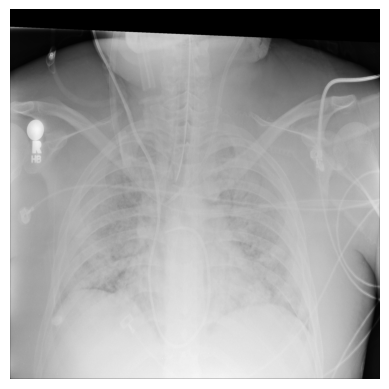

In [ ]:
# Loading an image
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays/00003923_015.png"

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
image_name = df_xray.iloc[0]["Image Index"]
image_name

'00000001_000.png'

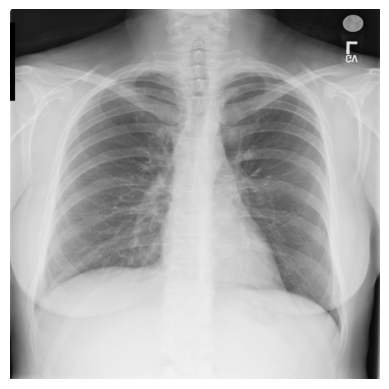

In [ ]:
# Load Images Using Metadata
image_name = df_xray.iloc[15026]["Image Index"]

image_path = f"/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays/{image_name}"

img = Image.open(image_path)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import os

image_folder = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays"

image_files = set(os.listdir(image_folder))

print("Images in folder:", len(image_files))
print(list(image_files)[:5])

Images in folder: 400
['00018398_000.png', '00016051_015.png', '00018404_000.png', '00004310_000.png', '00009236_000.png']


In [ ]:
filtered_df = df_xray[df_xray["Image Index"].isin(image_files)]

print("Metadata rows found:", len(filtered_df))
filtered_df.head()

Metadata rows found: 400


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
15000,00003923_015.png,Infiltration,15,3923,28,M,AP,2500,2048,0.171,0.171
15026,00003940_000.png,No Finding,0,3940,42,F,PA,2048,2500,0.171,0.171
15538,00004069_001.png,No Finding,1,4069,43,F,PA,2786,2592,0.143,0.143
15628,00004100_000.png,No Finding,0,4100,10,M,PA,2048,2500,0.171,0.171
15661,00004118_001.png,No Finding,1,4118,23,M,PA,2048,2500,0.171,0.171


In [ ]:
filtered_df.shape

(400, 11)

In [ ]:
image_dir = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays"

images = []

for img_name in filtered_df["Image Index"]:
    img_path = os.path.join(image_dir, img_name)
    images.append(Image.open(img_path))

In [ ]:
len(images)

400

So now we have pubmed dataset preprocessed and also the images. we can now move on to phase 5 to create multimodal extension

# ** Phase 5 Multimodal Extension**

In [ ]:
# Text embedding
from sentence_transformers import SentenceTransformer
import numpy as np

text_model = SentenceTransformer('all-MiniLM-L6-v2')

# Corrected: Use the 'df' DataFrame's 'text' column
paper_texts = df["text"].fillna("").tolist()

text_embeddings = text_model.encode(
    paper_texts,
    convert_to_tensor=True,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# image embedding
from transformers import CLIPProcessor, CLIPModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
image_embeddings = []

for img in images:

    inputs = processor(
        images=img,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        # Access pooler_output to get the actual embedding tensor
        feat = clip_model.get_image_features(**inputs).pooler_output

    feat = feat / feat.norm(dim=-1, keepdim=True)

    image_embeddings.append(
        feat.cpu().numpy()[0]
    )

image_embeddings = np.array(image_embeddings)

In [ ]:
# Generate image-style embedding for query
query = "Find documents about lung tumor progression with radiology evidence"

inputs = processor(
    text=query,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    # Access pooler_output to get the actual embedding tensor from text features
    query_embedding_image_wrapper = clip_model.get_text_features(**inputs)
    query_embedding_image = query_embedding_image_wrapper.pooler_output

query_embedding_image = query_embedding_image.squeeze()

print("Query image-style embedding generated.")

Query image-style embedding generated.


In [ ]:
# Calculate cosine similarity for text and image embeddings
import torch
from sentence_transformers import util

# For text-based document retrieval
query_embedding_text = text_model.encode(
    query,
    convert_to_tensor=True
)
text_scores = util.cos_sim(query_embedding_text, text_embeddings)[0]

# For image-based document retrieval (query text against image embeddings)
image_scores = util.cos_sim(query_embedding_image, torch.from_numpy(image_embeddings))[0]

print("Similarity scores calculated for both text and image modalities.")

Similarity scores calculated for both text and image modalities.


In [ ]:
# Retrieve top 5 documents based on text similarity

top_text_results = torch.topk(text_scores, k=5)
top_text_indices = top_text_results.indices.tolist()
top_text_scores = top_text_results.values.tolist()

print("Top 5 documents based on text similarity:")
for i, (idx, score) in enumerate(zip(top_text_indices, top_text_scores), 1):
    print(f"\nRank {i}:")
    print(f"Document ID: {idx}")
    print(f"Score: {score:.4f}")
    print(f"Title: {df.iloc[idx]['title']}")
    print(f"Text: {df.iloc[idx]['text'][:300]}...")

Top 10 documents based on text similarity:

Rank 1:
Document ID: 57
Score: 0.3837
Title: Current practices in cancer spatial data analysis: a call for guidance
Text: Current practices in cancer spatial data analysis: a call for guidance Review Background Recently, the North American Association of Central Cancer Registries (NAACCR) formed a Geographic Information Systems (GIS) Task Force that prepared a handbook to aid cancer registry staff in using GIS for the ...

Rank 2:
Document ID: 56
Score: 0.3403
Title: Dynamic changes of serum SARS-Coronavirus IgG, pulmonary function and radiography in patients recovering from SARS after hospital discharge
Text: Dynamic changes of serum SARS-Coronavirus IgG, pulmonary function and radiography in patients recovering from SARS after hospital discharge Introduction Severe acute respiratory syndrome (SARS) is a new infectious disease in humans. The first victim of SARS to be diagnosed was a businessman from the...

Rank 3:
Document ID: 2
Score: 0.2


Top 10 documents based on image similarity (query text against image embeddings):

Rank 1:
Image Index: 00016052_023.png
Score: 0.3177


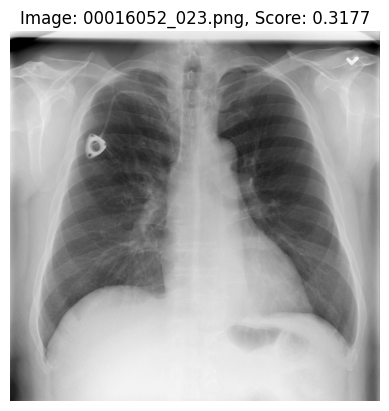


Rank 2:
Image Index: 00020959_004.png
Score: 0.3175


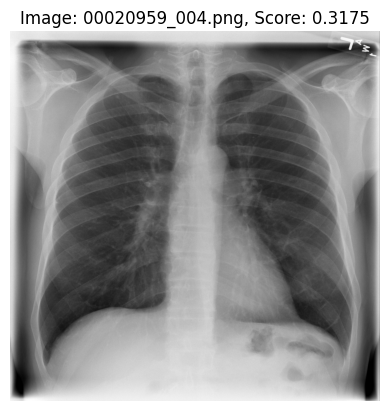


Rank 3:
Image Index: 00009235_000.png
Score: 0.3175


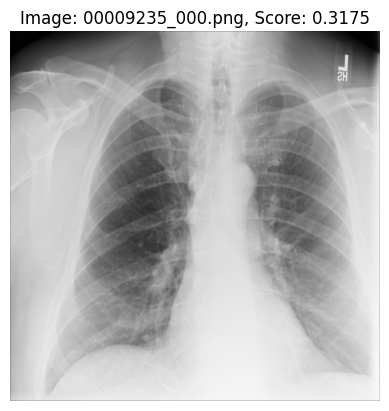


Rank 4:
Image Index: 00009237_028.png
Score: 0.3157


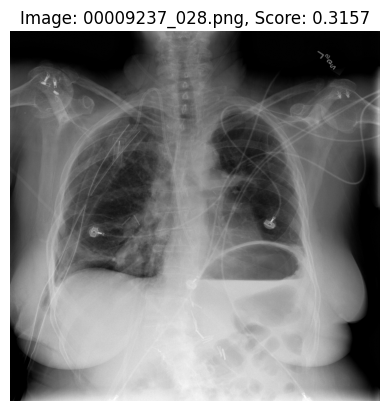


Rank 5:
Image Index: 00028181_000.png
Score: 0.3156


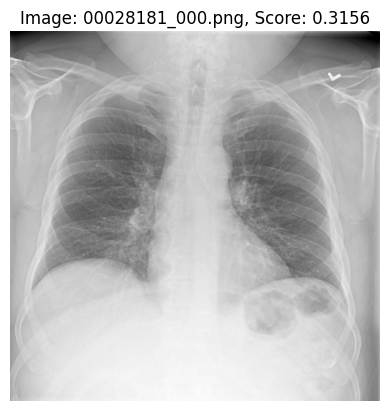

In [ ]:
# Retrieve top 5 documents based on image similarity (query text against image embeddings)

top_image_results = torch.topk(image_scores, k=5)
top_image_indices = top_image_results.indices.tolist()
top_image_scores = top_image_results.values.tolist()

print("\nTop 10 documents based on image similarity (query text against image embeddings):")
for i, (idx, score) in enumerate(zip(top_image_indices, top_image_scores), 1):
    print(f"\nRank {i}:")
    print(f"Image Index: {filtered_df.iloc[idx]['Image Index']}")
    print(f"Score: {score:.4f}")
    # Display the image
    from PIL import Image
    import matplotlib.pyplot as plt
    import os

    image_folder = "/content/drive/MyDrive/MMIR Assignment/NIH_Xray_Dataset/xrays"
    img_name = filtered_df.iloc[idx]['Image Index']
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path)

    plt.imshow(img, cmap="gray")
    plt.title(f"Image: {img_name}, Score: {score:.4f}")
    plt.axis("off")
    plt.show()